In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

BOS, EOS = ' ', '\n'

data = pd.read_json("D:\\RStudio\\nlp2\\arxivData.json")
lines = data.apply(lambda row: (row['title'] + ' ; ' + row['summary'])[:512], axis=1) \
    .apply(lambda line: BOS + line.replace(EOS, ' ') + EOS) \
    .tolist()
# if you missed the seminar, download data here - https://yadi.sk/d/_nGyU2IajjR9-w

In [13]:
# get all unique characters from lines (including capital letters and symbols)
tokens = set(''.join(lines))

tokens = sorted(tokens)
n_tokens = len(tokens)
print ('n_tokens = ',n_tokens)
assert 100 < n_tokens < 150
assert BOS in tokens, EOS in tokens

n_tokens =  136


In [14]:
# dictionary of character -> its identifier (index in tokens list)
token_to_id = {ch: i for i, ch in enumerate(tokens)}

In [15]:
assert len(tokens) == len(token_to_id), "dictionaries must have same size"
for i in range(n_tokens):
    assert token_to_id[tokens[i]] == i, "token identifier must be it's position in tokens list"

print("Seems alright!")

Seems alright!


In [16]:
def to_matrix(lines, max_len=None, pad=token_to_id[EOS], dtype=np.int64):
    """Casts a list of lines into torch-digestable matrix"""
    max_len = max_len or max(map(len, lines))
    lines_ix = np.full([len(lines), max_len], pad, dtype=dtype)
    for i in range(len(lines)):
        line_ix = list(map(token_to_id.get, lines[i][:max_len]))
        lines_ix[i, :len(line_ix)] = line_ix
    return lines_ix

In [17]:
#Example: cast 4 random names to a single matrix, pad with zeros where needed.
dummy_lines = [
    ' abc\n',
    ' abacaba\n',
    ' abc1234567890\n',
]
print(to_matrix(dummy_lines))

[[ 1 66 67 68  0  0  0  0  0  0  0  0  0  0  0]
 [ 1 66 67 66 68 66 67 66  0  0  0  0  0  0  0]
 [ 1 66 67 68 18 19 20 21 22 23 24 25 26 17  0]]


In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FixedWindowLanguageModel(nn.Module):
    def __init__(self, n_tokens=n_tokens, emb_size=16, hid_size=64):
        """
        A fixed window model that looks on at least 5 previous symbols.

        Note: fixed window LM is effectively performing a convolution over a sequence of words.
        This convolution only looks on current and previous words.
        Such convolution can be represented as a sequence of 2 operations:
        - pad input vectors by {strides * (filter_size - 1)} zero vectors on the "left", do not pad right
        - perform regular convolution with {filter_size} and {strides}

        - If you're absolutely lost, here's a hint: use nn.ZeroPad2d((NUM_LEADING_ZEROS, 0, 0, 0))
          followed by a nn.Conv1d(..., padding=0). And yes, its okay that padding is technically "2d".
        """
        super().__init__() # initialize base class to track sub-layers, trainable variables, etc.

        # YOUR CODE - create layers/variables and any metadata you want, e.g. self.emb = L.Embedding(...)
        self.n_tokens = n_tokens
        self.emb = nn.Embedding(n_tokens, emb_size)

        # будем смотреть на текущий + 5 предыдущих символов
        self.window_size = 6
        self.pad = nn.ZeroPad2d((self.window_size - 1, 0, 0, 0))  # (left, right, top, bottom)

        self.conv = nn.Conv1d(
            in_channels=emb_size,
            out_channels=hid_size,
            kernel_size=self.window_size,
            padding=0
        )
        self.proj = nn.Linear(hid_size, n_tokens)
        #END OF YOUR CODE

    def __call__(self, input_ix):
        """
        compute language model logits given input tokens
        :param input_ix: batch of sequences with token indices, tensor: int32[batch_size, sequence_length]
        :returns: pre-softmax linear outputs of language model [batch_size, sequence_length, n_tokens]
            these outputs will be used as logits to compute P(x_t | x_0, ..., x_{t - 1})

        :note: that convolutions operate with tensors of shape [batch, channels, length], while linear layers
         and *embeddings* use [batch, length, channels] tensors. Use tensor.permute(...) to adjust shapes.

        """
        # YOUR CODE - apply layers, see docstring above
        # input_ix: [batch, seq_len]
        x = self.emb(input_ix)               # [B, L, E]
        x = x.permute(0, 2, 1)              # [B, E, L]
        x = x.unsqueeze(2)                  # [B, E, 1, L]
        x = self.pad(x)                     # [B, E, 1, L+pad]
        x = x.squeeze(2)                    # [B, E, L+pad]
        x = self.conv(x)                    # [B, H, L]
        x = x.permute(0, 2, 1)              # [B, L, H]
        logits = self.proj(x)               # [B, L, V]
        return logits # output tensor should be of shape [batch_size, sequence_length, n_tokens]

    def get_possible_next_tokens(self, prefix=BOS, temperature=1.0, max_len=100):
        """ :returns: probabilities of next token, dict {token : prob} for all tokens """
        prefix_ix = torch.as_tensor(to_matrix([prefix]), dtype=torch.int64)
        with torch.no_grad():
            probs = torch.softmax(self(prefix_ix)[0, -1], dim=-1).cpu().numpy()  # shape: [n_tokens]
        return dict(zip(tokens, probs))

In [19]:
dummy_model = FixedWindowLanguageModel()

dummy_input_ix = torch.as_tensor(to_matrix(dummy_lines))
dummy_logits = dummy_model(dummy_input_ix)

print('Weights:', tuple(name for name, w in dummy_model.named_parameters()))

Weights: ('emb.weight', 'conv.weight', 'conv.bias', 'proj.weight', 'proj.bias')


In [20]:
assert isinstance(dummy_logits, torch.Tensor)
assert dummy_logits.shape == (len(dummy_lines), max(map(len, dummy_lines)), n_tokens), "please check output shape"
assert np.all(np.isfinite(dummy_logits.data.cpu().numpy())), "inf/nan encountered"
assert not np.allclose(dummy_logits.data.cpu().numpy().sum(-1), 1), "please predict linear outputs, don't use softmax (maybe you've just got unlucky)"

In [21]:
# test for lookahead
dummy_input_ix_2 = torch.as_tensor(to_matrix([line[:3] + 'e' * (len(line) - 3) for line in dummy_lines]))
dummy_logits_2 = dummy_model(dummy_input_ix_2)

assert torch.allclose(dummy_logits[:, :3], dummy_logits_2[:, :3]), "your model's predictions depend on FUTURE tokens. " \
                                                                   " Make sure you don't allow any layers to look ahead of current token." \
                                                                   " You can also get this error if your model is not deterministic (e.g. dropout). Disable it for this test."



In [22]:
def compute_mask(input_ix, eos_ix=token_to_id[EOS]):
    """ compute a boolean mask that equals "1" until first EOS (including that EOS) """
    return F.pad(torch.cumsum(input_ix == eos_ix, dim=-1)[..., :-1] < 1, pad=(1, 0, 0, 0), value=True)

print('matrix:\n', dummy_input_ix.numpy())
print('mask:', compute_mask(dummy_input_ix).to(torch.int32).cpu().numpy())
print('lengths:', compute_mask(dummy_input_ix).sum(-1).cpu().numpy())

matrix:
 [[ 1 66 67 68  0  0  0  0  0  0  0  0  0  0  0]
 [ 1 66 67 66 68 66 67 66  0  0  0  0  0  0  0]
 [ 1 66 67 68 18 19 20 21 22 23 24 25 26 17  0]]
mask: [[1 1 1 1 1 0 0 0 0 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]]
lengths: [ 5  9 15]


In [23]:
def compute_loss(model, input_ix):
    """
    :param model: language model that can compute next token logits given token indices
    :param input ix: int32 matrix of tokens, shape: [batch_size, length]; padded with eos_ix
    :returns: scalar loss function, mean crossentropy over non-eos tokens
    """
    input_ix = torch.as_tensor(input_ix, dtype=torch.int64)

    logits = model(input_ix[:, :-1])
    reference_answers = input_ix[:, 1:]

    # Your task: implement loss function as per formula above
    # your loss should only be computed on actual tokens, excluding padding
    # predicting actual tokens and first EOS do count. Subsequent EOS-es don't
    # you may or may not want to use the compute_mask function from above.

    mask = compute_mask(input_ix)[:, 1:]     # [B, L-1]
    mask = mask.to(logits.device)

    logits_flat = logits.reshape(-1, logits.size(-1))      # [B*(L-1), V]
    targets_flat = reference_answers.reshape(-1)           # [B*(L-1)]
    mask_flat = mask.reshape(-1).float()                   # [B*(L-1)]

    losses = F.cross_entropy(logits_flat, targets_flat, reduction='none')  # [B*(L-1)]
    loss = (losses * mask_flat).sum() / mask_flat.sum()

    return loss  # return scalar loss

In [24]:
loss_1 = compute_loss(dummy_model, to_matrix(dummy_lines, max_len=15))
loss_2 = compute_loss(dummy_model, to_matrix(dummy_lines, max_len=16))
assert (np.ndim(loss_1) == 0) and (0 < loss_1 < 100), "loss must be a positive scalar"
assert torch.allclose(loss_1, loss_2), 'do not include  AFTER first EOS into loss. ' \
                                       'Hint: use compute_mask. Beware +/-1 errors. And be careful when averaging!'


In [25]:
def score_lines(model, dev_lines, batch_size):
    """ computes average loss over the entire dataset """
    dev_loss_num, dev_loss_len = 0., 0.
    with torch.no_grad():
        for i in range(0, len(dev_lines), batch_size):
            batch_ix = to_matrix(dev_lines[i: i + batch_size])
            dev_loss_num += compute_loss(model, batch_ix).item() * len(batch_ix)
            dev_loss_len += len(batch_ix)
    return dev_loss_num / dev_loss_len

def generate(model, prefix=BOS, temperature=1.0, max_len=100):
    """
    Samples output sequence from probability distribution obtained by model
    :param temperature: samples proportionally to model probabilities ^ temperature
        if temperature == 0, always takes most likely token. Break ties arbitrarily.
    """
    with torch.no_grad():
        while True:
            token_probs = model.get_possible_next_tokens(prefix)
            tokens, probs = zip(*token_probs.items())
            if temperature == 0:
                next_token = tokens[np.argmax(probs)]
            else:
                probs = np.array([p ** (1. / temperature) for p in probs])
                probs /= sum(probs)
                next_token = np.random.choice(tokens, p=probs)

            prefix += next_token
            if next_token == EOS or len(prefix) > max_len: break
    return prefix

In [31]:
from sklearn.model_selection import train_test_split
train_lines, dev_lines = train_test_split(lines, test_size=0.25, random_state=42)

batch_size = 256
score_dev_every = 250
train_history, dev_history = [], []
model = FixedWindowLanguageModel()
opt = torch.optim.Adam(model.parameters())

# hint: if you ever wanted to switch to cuda, do it now.

# score untrained model
dev_history.append((0, score_lines(model, dev_lines, batch_size)))
print("Sample before training:", generate(model, 'Bridging'))

Sample before training: BridgingUãátG8ây(μρΣB*OŁ:/*pq/nG+aτ1mν42pσQ@O8kvOAqRIÉχ



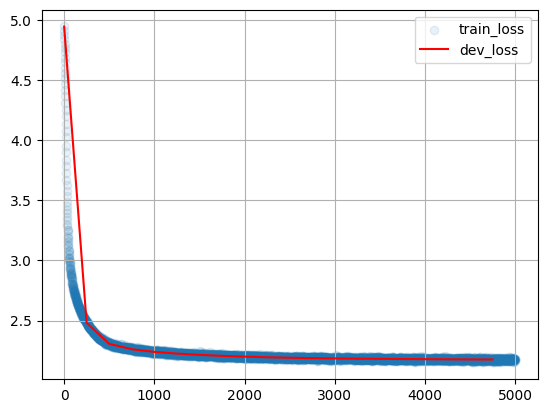

Generated examples (tau=0.5):
 Appricane the matho a the works ; In seaction probestor semmation lysetint on whthe propremont at in
 Al aralization and andition s formation thes are of rat on formeltis and is as on the sest actinge a
 Spation ath simalis tam te cones and and compticints. The tho math inge stremporing se cheare conent
Scoring dev...


100%|██████████████████████████████████████████████████████████████████████████████| 5000/5000 [13:26<00:00,  6.20it/s]

#4999 Dev loss: 2.176


In [32]:
from IPython.display import clear_output
from random import sample
from tqdm import trange

for i in trange(len(train_history), 5000):
    batch = to_matrix(sample(train_lines, batch_size))

    loss_i = compute_loss(model, batch)

    opt.zero_grad()
    loss_i.backward()
    opt.step()

    train_history.append((i, loss_i.item()))

    if (i + 1) % 50 == 0:
        clear_output(True)
        plt.scatter(*zip(*train_history), alpha=0.1, label='train_loss')
        if len(dev_history):
            plt.plot(*zip(*dev_history), color='red', label='dev_loss')
        plt.legend(); plt.grid(); plt.show()
        print("Generated examples (tau=0.5):")
        for _ in range(3):
            print(generate(model, temperature=0.5))

    if (i + 1) % score_dev_every == 0:
        print("Scoring dev...")
        dev_history.append((i, score_lines(model, dev_lines, batch_size)))
        print('#%i Dev loss: %.3f' % dev_history[-1])

In [33]:
assert np.mean(train_history[:10], axis=0)[1] > np.mean(train_history[-10:], axis=0)[1], "The model didn't converge."
print("Final dev loss:", dev_history[-1][-1])

for i in range(10):
    print(generate(model, temperature=0.5))

Final dev loss: 2.1757459186926122
 A Rentrancoratimans ing is are te ing ion mation the se worngem tha dedenlow the puston tion lation 
 Adily formant persenon the sing inations for compreat on weres oncalle tha lation arion-comate extio
 Sparis for use pory the ses le prine the chale mong alen tion tho neralen conve aras inaly detor and
 Seation ; The seralize tha fint ifure perection lowith areation s ing arfor ation s thes bation camp
 Learning ant on fored con tho inal Network thas exte cestive dodel ines puchese the ar anting are po
 SAIn. This papprextion sta s enters the the are tho mparion the reascontichingerens the sent ons of 
 Con tha de perection thon the  formention of intwel tion lation th we proprese to s in the seallor a
 Asperse tha dis matho spariand tion man-lation and inge te serant couss of omeles-ange se porecomint
 Stabes ing the me tod the cousent an weres apreproment anterand tion the sing at onstis and malel-se
 Spprexe forinimand at onte moding ares es ofor

In [34]:
class RNNLanguageModel(nn.Module):
    def __init__(self, n_tokens=n_tokens, emb_size=16, hid_size=256):
        """
        Build a recurrent language model.
        You are free to choose anything you want, but the recommended architecture is
        - token embeddings
        - one or more LSTM/GRU layers with hid size
        - linear layer to predict logits

        :note: if you use nn.RNN/GRU/LSTM, make sure you specify batch_first=True
         With batch_first, your model operates with tensors of shape [batch_size, sequence_length, num_units]
         Also, please read the docs carefully: they don't just return what you want them to return :)
        """
        super().__init__() # initialize base class to track sub-layers, trainable variables, etc.

        # YOUR CODE - create layers/variables/etc
        self.n_tokens = n_tokens
        self.emb = nn.Embedding(n_tokens, emb_size)
        self.rnn = nn.GRU(
            input_size=emb_size,
            hidden_size=hid_size,
            batch_first=True
        )
        self.proj = nn.Linear(hid_size, n_tokens)
        #END OF YOUR CODE

    def __call__(self, input_ix):
        """
        compute language model logits given input tokens
        :param input_ix: batch of sequences with token indices, tensor: int32[batch_size, sequence_length]
        :returns: pre-softmax linear outputs of language model [batch_size, sequence_length, n_tokens]
            these outputs will be used as logits to compute P(x_t | x_0, ..., x_{t - 1})
        """
        # YOUR CODE - apply layers, see docstring above
        x = self.emb(input_ix)          # [B, L, E]
        outputs, _ = self.rnn(x)        # [B, L, H]
        logits = self.proj(outputs)     # [B, L, V]
        return logits # output tensor should be of shape [batch_size, sequence_length, n_tokens]

    def get_possible_next_tokens(self, prefix=BOS, temperature=1.0, max_len=100):
        """ :returns: probabilities of next token, dict {token : prob} for all tokens """
        prefix_ix = torch.as_tensor(to_matrix([prefix]), dtype=torch.int64)
        with torch.no_grad():
            probs = torch.softmax(self(prefix_ix)[0, -1], dim=-1).cpu().numpy()  # shape: [n_tokens]
        return dict(zip(tokens, probs))

In [35]:
model = RNNLanguageModel()

dummy_input_ix = torch.as_tensor(to_matrix(dummy_lines))
dummy_logits = model(dummy_input_ix)

assert isinstance(dummy_logits, torch.Tensor)
assert dummy_logits.shape == (len(dummy_lines), max(map(len, dummy_lines)), n_tokens), "please check output shape"
assert not np.allclose(dummy_logits.cpu().data.numpy().sum(-1), 1), "please predict linear outputs, don't use softmax (maybe you've just got unlucky)"
print('Weights:', tuple(name for name, w in model.named_parameters()))

Weights: ('emb.weight', 'rnn.weight_ih_l0', 'rnn.weight_hh_l0', 'rnn.bias_ih_l0', 'rnn.bias_hh_l0', 'proj.weight', 'proj.bias')


In [36]:
# test for lookahead
dummy_input_ix_2 = torch.as_tensor(to_matrix([line[:3] + 'e' * (len(line) - 3) for line in dummy_lines]))
dummy_logits_2 = model(dummy_input_ix_2)

assert torch.allclose(dummy_logits[:, :3], dummy_logits_2[:, :3]), "your model's predictions depend on FUTURE tokens. " \
                                                                   " Make sure you don't allow any layers to look ahead of current token." \
                                                                   " You can also get this error if your model is not deterministic (e.g. dropout). Disable it for this test."



In [37]:
batch_size = 64         # <-- please tune batch size to fit your CPU/GPU configuration
score_dev_every = 250
train_history, dev_history = [], []

model = RNNLanguageModel(n_tokens=n_tokens, emb_size=16, hid_size=256)
opt = torch.optim.Adam(model.parameters())

# score untrained model
dev_history.append((0, score_lines(model, dev_lines, batch_size)))
print("Sample before training:", generate(model, 'Bridging'))

Sample before training: BridgingLΣ@1õâμZce'tÖΣ&K^°âXNèàIàu(fã/RaUâzj41,cpKCfzuτrH#"I\9Ü%)XIZMZc47<



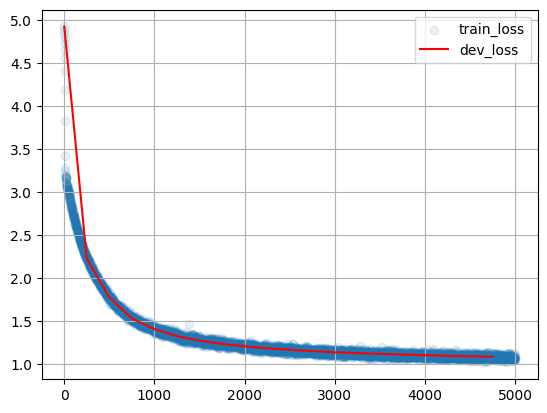

Generated examples (tau=0.5):
 Set Algorithms for Series on Approximate Decision Matrix   Video ; Many machine learning is the inpu
 A Network to Simple Convex Analysis of Machine Learning ; We address the most proposed algorithm for
 Faster Supervised Deterministic Distributions ; This paper presents a new approach for extracting a 
Scoring dev...


100%|██████████████████████████████████████████████████████████████████████████████| 5000/5000 [51:05<00:00,  1.63it/s]

#4999 Dev loss: 1.077


In [38]:
from IPython.display import clear_output
from random import sample
from tqdm import trange

for i in trange(len(train_history), 5000):
    batch = to_matrix(sample(train_lines, batch_size))

    # YOUR CODE - one step of the training loop for your RNN model
    loss_i = compute_loss(model, batch)
    opt.zero_grad()
    loss_i.backward()
    opt.step()

    train_history.append((i, float(loss_i)))

    if (i + 1) % 50 == 0:
        clear_output(True)
        plt.scatter(*zip(*train_history), alpha=0.1, label='train_loss')
        if len(dev_history):
            plt.plot(*zip(*dev_history), color='red', label='dev_loss')
        plt.legend(); plt.grid(); plt.show()
        print("Generated examples (tau=0.5):")
        for _ in range(3):
            print(generate(model, temperature=0.5))

    if (i + 1) % score_dev_every == 0:
        print("Scoring dev...")
        dev_history.append((i, score_lines(model, dev_lines, batch_size)))
        print('#%i Dev loss: %.3f' % dev_history[-1])

In [39]:
assert np.mean(train_history[:10], axis=0)[1] > np.mean(train_history[-10:], axis=0)[1], "The model didn't converge."
print("Final dev loss:", dev_history[-1][-1])
for i in range(10):
    print(generate(model, temperature=0.5))

Final dev loss: 1.0771419823576764
 Learning Model Convex Decomposition ; For the selection method that selection of a word specific inf
 A Complex Distributed Semantic Embedding for Complex Analysis ; The problem of sensing assumptions a
 A Segmentation to Applications with Multi-Statistical Networks ; The natural context of fusion of su
 Language Segmentation Recognition for Action Networks ; Convolutional Neural Networks (ASP) have bee
 A Segmentation of Recognition in Sentence Sentences ; We propose a novel algorithm for the ranking o
 Ensemble Sections with Multi-of-Convolutional Neural Networks ; The general model is a probability o
 Weighted Regularization of Structure Based Segmentation ; In this paper, we propose a new function f
 Multiple Consistent Specification ; The problem of recognition have leverent inference in the many a
 A Network for Compositional Latent Transformation ; We present a new approach to be proposed and sta
 Convolutional Neural Networks for Speech Outpu

In [40]:
def generate_nucleus(model, prefix=BOS, nucleus=0.9, max_len=100):
    """
    Generate a sequence with nucleus sampling
    :param prefix: a string containing space-separated previous tokens
    :param nucleus: N from the formulae above, N \in [0, 1]
    :param max_len: generate sequences with at most this many tokens, including prefix

    :note: make sure that nucleus always contains at least one word, even if p(w*) > nucleus

    """
    while True:
        token_probs = model.get_possible_next_tokens(prefix)
        tokens, probs = zip(*token_probs.items())

        probs = np.array(probs, dtype='float64')
        tokens = np.array(tokens)

        # сортируем по убыванию вероятности
        order = np.argsort(probs)[::-1]
        probs_sorted = probs[order]
        tokens_sorted = tokens[order]

        cumsum = np.cumsum(probs_sorted)
        cutoff = np.searchsorted(cumsum, nucleus, side='left') + 1
        cutoff = max(1, cutoff)

        probs_top = probs_sorted[:cutoff]
        tokens_top = tokens_sorted[:cutoff]
        probs_top = probs_top / probs_top.sum()

        next_token = np.random.choice(tokens_top, p=probs_top)

        prefix += next_token
        if next_token == EOS or len(prefix) > max_len: break
    return prefix

<>:5: SyntaxWarning: invalid escape sequence '\i'
<>:5: SyntaxWarning: invalid escape sequence '\i'
C:\Users\sasha\AppData\Local\Temp\ipykernel_34960\2932593754.py:5: SyntaxWarning: invalid escape sequence '\i'
  :param nucleus: N from the formulae above, N \in [0, 1]


In [42]:
def generate_nucleus(model, prefix=BOS, nucleus=0.9, max_len=100):
    """
    Generate a sequence with nucleus sampling
    :param prefix: a string containing space-separated previous tokens
    :param nucleus: N from the formulae above, N \in [0, 1]
    :param max_len: generate sequences with at most this many tokens, including prefix

    :note: make sure that nucleus always contains at least one word, even if p(w*) > nucleus

    """
    while True:
        token_probs = model.get_possible_next_tokens(prefix)
        tokens, probs = zip(*token_probs.items())

        probs = np.array(probs, dtype='float64')
        tokens = np.array(tokens)

        # сортируем по убыванию вероятности
        order = np.argsort(probs)[::-1]
        probs_sorted = probs[order]
        tokens_sorted = tokens[order]

        cumsum = np.cumsum(probs_sorted)
        cutoff = np.searchsorted(cumsum, nucleus, side='left') + 1
        cutoff = max(1, cutoff)

        probs_top = probs_sorted[:cutoff]
        tokens_top = tokens_sorted[:cutoff]
        probs_top = probs_top / probs_top.sum()

        next_token = np.random.choice(tokens_top, p=probs_top)

        prefix += next_token
        if next_token == EOS or len(prefix) > max_len: break
    return prefix

<>:5: SyntaxWarning: invalid escape sequence '\i'
<>:5: SyntaxWarning: invalid escape sequence '\i'
C:\Users\sasha\AppData\Local\Temp\ipykernel_34960\2932593754.py:5: SyntaxWarning: invalid escape sequence '\i'
  :param nucleus: N from the formulae above, N \in [0, 1]


In [44]:
for i in range(10):
    print(generate_nucleus(model, nucleus=0.85, max_len=200).strip(), "\n")

A Machine Procedusive Perceptrof on Model ; We diverse more an optimal variation of directions in class data, for the tree task where the object recognition of different applications to continuous mos 

Sifferent Decide Modeling using Arabic Matrix Clustering (MDP) for Complex Space Image   Optimization ; In this paper, we present an effective advanced theoretical function of data associations from t 

A Parameter Inference of Experimental Action of Deep Learning Meta-Machine   Distortagts to Diagnostic Target Regite ; The consistency of a fast machine can capture distributions of data in only the g 

Convolutional Models for Labeling Search ; We present an observation parallel algorithm for the point of ensericed detection and multimodal earlies of its making description for point compositionality 

Choose Time-Arder Tool-Filli-Out Multiple Symbolic Based Sentiment Extraction and Non-Interaction Reduction ; In particular, expression in the parameter increasing solution is used and pre

In [ ]:
from IPython.display import HTML
# Here's what it looks like:
!wget -q https://raw.githubusercontent.com/yandexdataschool/nlp_course/2020/resources/beam_search.html
HTML("beam_search.html")

In [ ]:
def generate_beamsearch(model, prefix=BOS, beam_size=4, length=5):
    """
    Generate a sequence with beam search
    :param prefix: a string containing space-separated previous tokens
    :param beam_size: maintain this many top-k hypotheses in beam
    :param length: generate sequences with at most this many tokens, NOT INCLUDING PREFIX
    :returns: beam_size most likely candidates
    """

    # beam: list of (sequence_string, log_prob)
    beam = [(prefix, 0.0)]

    for _ in range(length):
        new_beam = []
        for seq, log_prob in beam:
            # если уже EOS в конце, просто переносим гипотезу
            if seq.endswith(EOS):
                new_beam.append((seq, log_prob))
                continue

            token_probs = model.get_possible_next_tokens(seq)
            for token, prob in token_probs.items():
                if prob <= 0.0:
                    continue
                new_seq = seq + token
                new_log_prob = log_prob + np.log(prob + 1e-9)
                new_beam.append((new_seq, new_log_prob))

        new_beam.sort(key=lambda x: x[1], reverse=True)
        beam = new_beam[:beam_size]

        if all(seq.endswith(EOS) for seq, _ in beam):
            break

    best_seq, _ = max(beam, key=lambda x: x[1])
    return best_seq

In [ ]:
generate_beamsearch(model, prefix=' deep ', beam_size=4)